## Setup

This project uses NVIDIA’s Earth-2 (Earth2Studio) framework.

### Prerequisites

- NVIDIA Earth-2 (Earth2Studio)
- Python 3.12 kernel
- `uv` (recommended)


If you do not have `uv` installed, follow the installation instructions for your system:
https://docs.astral.sh/uv/getting-started/installation/

### Python kernel

To install the proper kernel, run ```uv run python -m ipykernel install --user --name earth2 --display-name "Earth2 (Python 3.12)"```

For most users, follow the official Earth-2 installation guide:
https://docs.nvidia.com/earth-2/


In [2]:
from datetime import datetime
import earth2studio.run as run
from earth2studio.models.px import FCN
from earth2studio.models.px import FCN3
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.dx import PrecipitationAFNO
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import os

In [6]:
os.chdir("earth2studio-project")

/home/jovyan/earth2studio-project


# Run the cell below to ensure you have enough GPU memory
If you need to kill a process, run ```kill -9 {PID}``` in your terminal


### 2m Air Temperature Forecast (T+24h)

In [2]:
os.chdir("/home/jovyan/earth2studio-project")
model = FCN.load_model(FCN.load_default_package())
data = GFS()
io = ZarrBackend("t2m_outputs/fcn_gfs_forecast.zarr", backend_kwargs={'overwrite': True})

In [3]:
nsteps = 10
io = run.deterministic(["2026-01-08"], nsteps, model, data, io)
print(io.root.tree())

2026-01-15 05:29:35.033 | INFO     | earth2studio.run:deterministic:75 - Running simple workflow!
2026-01-15 05:29:35.034 | INFO     | earth2studio.run:deterministic:82 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-01-15 05:29:35.325 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 420824303-1176329


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-01-15 05:29:35.897 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-01-15 05:29:35.933 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-01-15 05:29:35.966 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-01-15 05:29:36.000 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 329645190-898530
2026-01-15 05:29:36.033 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 413181533-966042
2026-01-15 05:29:36.067 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS 

...

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 18.60it/s]


2026-01-15 05:29:36.558 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253820556-806142
2026-01-15 05:29:36.591 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-01-15 05:29:36.623 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 398557080-950478
2026-01-15 05:29:36.657 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 331385039-869528
2026-01-15 05:29:36.689 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 336364985-938149
2026-01-15 05:29:36.814 | SUCCESS  | earth2studio.run:deterministic:106 - Fetched data fro


Running inference: 100%|██████████| 11/11 [00:36<00:00,  3.29s/it]

2026-01-15 05:30:13.032 | SUCCESS  | earth2studio.run:deterministic:146 - Inference complete


/
├── lat (720,) float64
├── lead_time (11,) timedelta64
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32
├── z250 (1, 11, 720, 1440) float32
├── z50 (1, 11, 720, 1440) float32
├── z500 (1, 11, 720, 1440) float32
└── z850 (1, 11, 720, 1440) float32

In [15]:
# plot t2m
def plot_prediction(ds, variable, step):
    plt.close("all")
    forecast = "2026-01-08 Prediction"
    # Create a Robinson projection
    projection = ccrs.Robinson()

    # Create a figure and axes with the specified projection
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))

    # Plot the field using pcolormesh
    im = ax.pcolormesh(
        ds["lon"],
        ds["lat"],
        ds[variable][0, step],
        transform=ccrs.PlateCarree(),
        cmap="Spectral_r",
    )
    # temperature bar
    cbar = plt.colorbar(im, ax = ax, orientation = "horizontal", pad = 0.05)
    cbar.set_label("Temperature (K)")

    # Set title
    ax.set_title(f"{forecast} - Lead time: {6*step}hrs")

    # Add coastlines and gridlines
    ax.coastlines()
    ax.gridlines()
    plt.savefig("/home/jovyan/earth2studio-project/t2m_outputs/07_t2m_prediction.jpg")

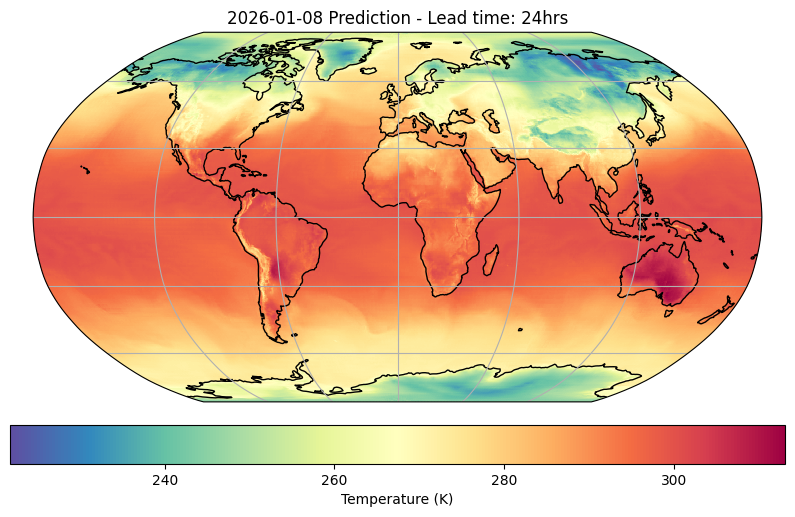

In [16]:
# plot t2m
ds = xr.open_zarr("/home/jovyan/earth2studio-project/t2m_outputs/fcn_gfs_forecast.zarr")
plot_prediction(ds, "t2m", 4)

### Total Precipitation Forecast

In [2]:
prognostic_model = FCN.load_model(FCN.load_default_package())
package = PrecipitationAFNO.load_default_package()
diagnostic_model = PrecipitationAFNO.load_model(package)
io = ZarrBackend("/home/jovyan/earth2studio-project/tp_outputs/fcn_gfs_forecast.zarr", backend_kwargs={'overwrite': True})
data = GFS()

#Max precipitation for hurricane
#pressure for hurricane

In [3]:
nsteps = 10
io = run.diagnostic(
    ["2026-01-01"],
    nsteps,
    prognostic_model,
    diagnostic_model,
    data,
    io
)
print(io.root.tree())

2026-01-15 05:32:08.326 | INFO     | earth2studio.run:diagnostic:190 - Running diagnostic workflow!
2026-01-15 05:32:08.328 | INFO     | earth2studio.run:diagnostic:197 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-01-15 05:32:08.700 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 259342047-725865


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-01-15 05:32:09.250 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 400502176-971362
2026-01-15 05:32:09.276 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 205551634-750666
2026-01-15 05:32:09.301 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 151972051-755588
2026-01-15 05:32:09.327 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 401473538-960078
2026-01-15 05:32:09.353 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 422123816-947538
2026-01-15 05:32:09.378 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS 

...

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 21.82it/s]


2026-01-15 05:32:09.863 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 204810809-740825
2026-01-15 05:32:10.026 | SUCCESS  | earth2studio.run:diagnostic:220 - Fetched data from GFS
2026-01-15 05:32:10.046 | INFO     | earth2studio.run:diagnostic:252 - Inference starting!



Running inference: 100%|██████████| 11/11 [00:03<00:00,  2.93it/s]

2026-01-15 05:32:13.804 | SUCCESS  | earth2studio.run:diagnostic:266 - Inference complete


/
├── lat (720,) float64
├── lead_time (11,) timedelta64
├── lon (1440,) float64
├── time (1,) datetime64
└── tp (1, 11, 720, 1440) float32

In [61]:
def plot_tp(ds, variable, step, extent):
    plt.close("all")
    forecast = datetime(2026, 1, 1)
    # Create a Orthographic projection of USA
    #projection = ccrs.Orthographic(-100, 40)
    projection = ccrs.Robinson()

    # Create a figure and axes with the specified projection
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))

    # Plot the field using pcolormesh
    levels = np.arange(0.0, 0.01, 0.001)
    im = ax.contourf(
        ds["lon"],
        ds["lat"],
        ds[variable][0, step],
        levels,
        transform=ccrs.PlateCarree(),
        vmax=0.01,
        vmin=0.00,
        cmap="terrain",
        extend="max"
    )

    # Set title
    ax.set_title(f"{forecast.strftime('%Y-%m-%d')} - Lead time: {6*step}hrs")

    # Add coastlines and gridlines6
    ax.set_extent(extent)  # [lat min, lat max, lon min, lon max]
    ax.coastlines()
    ax.gridlines()
    plt.colorbar(
        im, ax=ax, ticks=levels, shrink=0.75, pad=0.04, label="Total precipitation (m)"
    )
    #plt.savefig("/home/jovyan/earth2studio-project/tp_outputs/02_tp_prediction.jpg")
    #plt.close(fig)

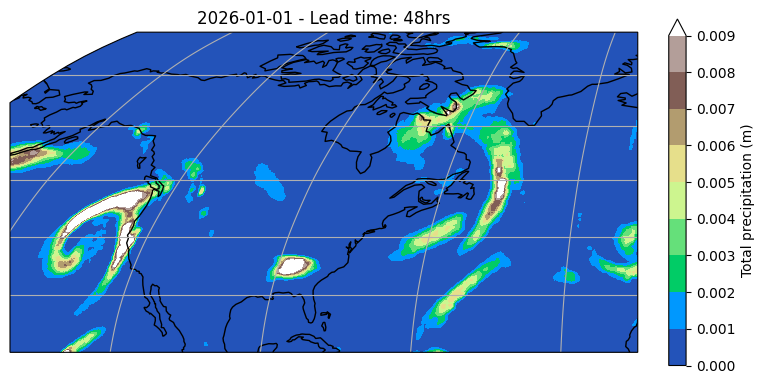

In [65]:
ds = xr.open_zarr("/home/jovyan/earth2studio-project/tp_outputs/fcn_gfs_forecast.zarr")

extent=[220, 340, 20, 70]
plot_tp(ds, "tp", 8, extent)

# extent=[230, 250, 30, 45]
# plot_tp(ds, "tp", 8, extent)

## Hurricane Florence

uv add earth2studio --extra cyclone

uv add earth2studio --extra graphcast

### GraphCastOperational

In [23]:
import os
import torch
from earth2studio.models.px import GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import WB2ERA5
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from datetime import datetime, timedelta

os.chdir("/home/jovyan/earth2studio-project")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tracker = TCTrackerWuDuan()

package = GraphCastOperational.load_default_package()
graphcast_model = GraphCastOperational.load_model(package)
# prognostic = GraphCastOperational()

# data = ARCO()
data = WB2ERA5(cache=True, verbose=True)
os.makedirs("florence_outputs", exist_ok=True)

nsteps = 25
start_time = datetime(2018, 9, 13)
end_time = start_time + timedelta(hours=6 * nsteps)

print("Done")


Done


In [24]:
from tqdm import tqdm
from earth2studio.utils.coords import map_coords
from earth2studio.data import fetch_data

graphcast_operational_model = graphcast_model.to(device)

tracker.reset_path_buffer() #reset tracker

x, coords = fetch_data(
    source=data,
    time=to_time_array([start_time]),
    variable=graphcast_operational_model.input_coords()["variable"],
    lead_time=graphcast_operational_model.input_coords()["lead_time"],
    device=device
)

x, coords = map_coords(x, coords, graphcast_operational_model.input_coords())

model = graphcast_operational_model.create_iterator(x, coords)
with tqdm(total=nsteps+1, desc="Running inference") as pbar:
    for steps, (x, coords) in enumerate(model):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, output_coords = tracker(x, coords)
        output = output[:,0]
        print(f"Step {steps}: GraphCast tracker output shape {output.shape}")
        pbar.update(1)
        if steps == nsteps:
            break
graphcast_operational_tracks = output.cpu()
torch.save(graphcast_operational_tracks, "florence_outputs/graphcast_operational_paths.pt")
print("Saved Graphcast paths")

Fetching WB2 data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-02-02 22:26:59.255 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t100 at 2018-09-12T18:00:00
2026-02-02 22:26:59.256 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v150 at 2018-09-12T18:00:00
2026-02-02 22:26:59.257 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t300 at 2018-09-12T18:00:00
2026-02-02 22:26:59.259 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t50 at 2018-09-12T18:00:00
2026-02-02 22:26:59.260 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v200 at 2018-09-12T18:00:00
2026-02-02 22:26:59.261 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t250 at 2018-09-12T18:00:00
2026-02-02 22:26:59.262 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-12T18:00:00


Fetching WB2 data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-02-02 22:27:01.840 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t250 at 2018-09-13T00:00:00
2026-02-02 22:27:01.842 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t300 at 2018-09-13T00:00:00
2026-02-02 22:27:01.843 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q925 at 2018-09-13T00:00:00
2026-02-02 22:27:01.844 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t200 at 2018-09-13T00:00:00
2026-02-02 22:27:01.845 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t150 at 2018-09-13T00:00:00
2026-02-02 22:27:01.847 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q700 at 2018-09-13T00:00:00
2026-02-02 22:27:01.848 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00

Running inference:   4%|▍         | 1/26 [00:02<00:50,  2.00s/it]

...

Step 23: GraphCast tracker output shape torch.Size([1, 25, 24, 4])


Running inference:  96%|█████████▌| 25/26 [01:09<00:00,  1.05it/s]

Step 24: GraphCast tracker output shape torch.Size([1, 26, 25, 4])


Running inference: 100%|██████████| 26/26 [01:10<00:00,  2.73s/it]

Step 25: GraphCast tracker output shape torch.Size([1, 27, 26, 4])
Saved Graphcast paths


### Era5

In [25]:
from earth2studio.data import fetch_data, prep_data_array, ARCO,WB2ERA5

# era5_data = ARCO()
era5_data = WB2ERA5(cache=True, verbose=True)
times = [start_time + timedelta(hours = 6 * i) for i in range(nsteps + 1)]

tracker.reset_path_buffer() #reset tracker

for step, time in enumerate(times):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=device)
    output, output_coords = tracker(x, coords)
    print(f"Step {step}: WB2 tracks output shape {output.shape}")

era5_tracks = output.cpu()
torch.save(era5_tracks, "florence_outputs/era5_paths.pt")
print("Saved era5 track")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 74.42it/s]


2026-02-02 22:28:36.499 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-02-02 22:28:36.500 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00
2026-02-02 22:28:36.501 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-02-02 22:28:36.502 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-02-02 22:28:36.504 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
Step 0: WB2 tracks output shape torch.Size([1, 12, 1, 4])


Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 75.79it/s]

2026-02-02 22:28:36.741 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-02-02 22:28:36.743 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00
2026-02-02 22:28:36.744 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-02-02 22:28:36.745 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-02-02 22:28:36.747 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00


Step 1: WB2 tracks output shape torch.Size([1, 13, 2, 4])


...

Step 24: WB2 tracks output shape torch.Size([1, 32, 25, 4])


Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-02-02 22:28:52.242 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
2026-02-02 22:28:52.243 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-02-02 22:28:52.244 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-02-02 22:28:52.245 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-02-02 22:28:52.246 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-02-02 22:28:52.335 | DEBUG    | earth2studio.data.utils:_make_local_details:657 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/v_component_of_wind/87245.0.0.0 to local cache
2026-02-02 22:28:52.336 | DEBUG    | earth2studio.data

Fetching WB2 data: 100%|██████████| 5/5 [00:01<00:00,  4.64it/s]

Step 25: WB2 tracks output shape torch.Size([1, 33, 26, 4])
Saved era5 track


### FCN

In [26]:
import os
import torch
from earth2studio.models.px import FCN
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import NCAR_ERA5
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from datetime import datetime, timedelta


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tracker = TCTrackerWuDuan()
FCN_data = NCAR_ERA5()
package = FCN.load_default_package()
FCN_model = FCN.load_model(package)
start_time = datetime(2018, 9, 13)
print("Done")

Done


In [27]:
from tqdm import tqdm
from earth2studio.utils.coords import map_coords
from earth2studio.data import fetch_data
from earth2studio.utils.type import CoordSystem

from tqdm import tqdm
from earth2studio.utils.coords import map_coords

FCN_model = FCN_model.to(device)

tracker.reset_path_buffer() #reset tracker

x, coords = fetch_data(
    source=FCN_data,
    time=to_time_array([start_time]),
    variable=FCN_model.input_coords()["variable"],
    lead_time=FCN_model.input_coords()["lead_time"],
    device=device
)

x, coords = map_coords(
    x,
    coords,
    FCN_model.input_coords(),
)

model = FCN_model.create_iterator(x, coords)
with tqdm(total=nsteps+1, desc="Running inference") as pbar:
    for step, (x, coords) in enumerate(model):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, output_coords = tracker(x, coords)
        output = output[:,0]

        print(f"Step {step}: FCN tracker output shape {output.shape}")

        pbar.update(1)
        if step == nsteps:
            break
FCN_tracks = output.cpu()
torch.save(FCN_tracks, "florence_outputs/fcn_paths.pt")


Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-02-02 22:29:03.129 | DEBUG    | earth2studio.data.ncar:fetch_array:313 - Fetching NCAR ERA5 variable: SP in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_134_sp.ll025sc.2018090100_2018093023.nc
2026-02-02 22:29:03.132 | DEBUG    | earth2studio.data.ncar:fetch_array:313 - Fetching NCAR ERA5 variable: 100V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.228_247_100v.ll025sc.2018090100_2018093023.nc
2026-02-02 22:29:03.138 | DEBUG    | earth2studio.data.ncar:fetch_array:313 - Fetching NCAR ERA5 variable: T in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_130_t.ll025sc.2018091300_2018091323.nc
2026-02-02 22:29:03.141 | DEBUG    | earth2studio.data.ncar:fetch_array:313 - Fetching NCAR ERA5 variable: 10V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_166_10v.ll025sc.2018090100_2018093023.nc
2026-02-02 22:29:03.144 | DEBUG    | earth2studio.data.ncar:fetch_array:313 - Fetching NCAR ERA5 variable: 100U in file s3://n

Running inference:   4%|▍         | 1/26 [00:00<00:04,  5.83it/s]

Step 0: FCN tracker output shape torch.Size([1, 12, 1, 4])


Running inference:   8%|▊         | 2/26 [00:00<00:05,  4.79it/s]

...

Step 20: FCN tracker output shape torch.Size([1, 23, 21, 4])
Step 21: FCN tracker output shape torch.Size([1, 24, 22, 4])


Running inference:  92%|█████████▏| 24/26 [00:04<00:00,  5.61it/s]

Step 22: FCN tracker output shape torch.Size([1, 24, 23, 4])
Step 23: FCN tracker output shape torch.Size([1, 24, 24, 4])


Running inference: 100%|██████████| 26/26 [00:04<00:00,  5.51it/s]

Step 24: FCN tracker output shape torch.Size([1, 24, 25, 4])
Step 25: FCN tracker output shape torch.Size([1, 24, 26, 4])


## Era5 vs Graphcast vs FCN

### Helper Functions

In [28]:
import matplotlib.patheffects as pe

#add city names for clearer plot
def add_cities(ax, city_list, default_offset=(0.22, 0.22),
               text_kw=None, marker_kw=None):
    if text_kw is None:
        text_kw = dict(fontsize=8, 
                       zorder=11,
                       path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                       transform=ccrs.PlateCarree())
    if marker_kw is None:
        marker_kw = dict(marker="o",
                         color="red",
                         markersize=3, 
                         zorder=10,
                         transform=ccrs.PlateCarree())

    for item in city_list:
        # item can be (name, lat, lon) or (name, lat, lon, dx, dy)
        if len(item) == 3:
            name, lat, lon = item
            dx, dy = default_offset
        else:
            name, lat, lon, dx, dy = item

        ax.plot(lon, lat, **marker_kw)
        ax.text(lon + dx, lat + dy, name, **text_kw)


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_hurricane_tracks(
    models,
    start_time=None,
    end_time=None,
    extent=(-95, -60, 30, 45),
    cities=None,
    title="Tropical Cyclone Tracks",
    figsize=(10, 8),
    show=True,
):
    projection = ccrs.Robinson()

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)

    # Map styling
    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    #ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    # Plot models
    for model in models:
        name = model["name"]
        tracks = model["tracks"]
        color = model.get("color", None)
        lw = model.get("lw", 2.0)
        ls = model.get("ls", "--")

        # torch → numpy
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_done = False

        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)

            if mask.any() and len(lons[mask]) > 2:
                ax.plot(
                    lons[mask],
                    lats[mask],
                    color=color,
                    linewidth=lw,
                    linestyle=ls,
                    label=name if not label_done else "",
                    transform=ccrs.PlateCarree(),
                    zorder=6,
                    # path_effects=[
                    #     pe.Stroke(linewidth=lw + 2.5, foreground="white"),
                    #     pe.Normal(),
    #],
                )
                label_done = True

    # Cities
    if cities is not None:
        add_cities(ax, cities)

    # Title
    if (start_time is not None) and (end_time is not None):
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")

    #plt.savefig("Florence(9-18).png", bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax


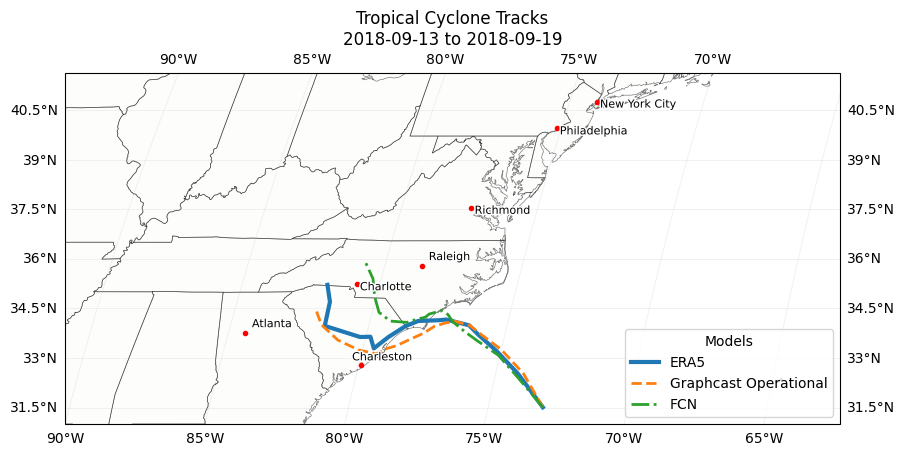

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Tropical Cyclone Tracks\n2018-09-13 to 2018-09-19'}>)

In [36]:

#load saved model paths
era5_load = torch.load("florence_outputs/era5_paths.pt", map_location="cpu")
graphcast_operational_load = torch.load("florence_outputs/graphcast_operational_paths.pt", map_location="cpu")
FCN_load = torch.load("florence_outputs/fcn_paths.pt", map_location="cpu")

# era5_paths = era5_load.numpy()
# graphcast_operational_paths = graphcast_operational_load.numpy()
# fcn_paths = FCN_load.numpy()

#list of cities to plot
cities = [
    # North Carolina
    ("Charlotte", 35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh", 35.7796, -78.6382,  0.18,  0.18),

    # South Carolina
    ("Charleston", 32.7765, -79.9311, -0.35,  0.15),

    # Other major cities
    ("Atlanta", 33.7490, -84.3880,  0.18,  0.18),
    ("Richmond", 37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18,  -0.18),
]

models = [
    {
        "name": "ERA5",
        "tracks": era5_load,
        "color": "#1f77b4",
        "lw": 3.0,
        "ls": "-"
    },
    {
        "name": "Graphcast Operational",
        "tracks": graphcast_operational_load,
        "color": "#ff7f0e",
        "lw": 2.0,
        "ls": "--"
    },
    {
        "name": "FCN",
        "tracks": FCN_load,
        "color": "#2ca02c",
        "lw": 2.0,
        "ls": "-."
    },
]
extent = (-90, -65, 31, 41)
plot_hurricane_tracks(
    models,
    start_time=start_time,
    end_time=end_time,
    extent=extent,
    cities=cities,
)


## Wind Visualizations

In [7]:
import os
from datetime import datetime
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import earth2studio.run as run
from earth2studio.models.px import GraphCastOperational
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend

os.chdir("/home/jovyan/earth2studio-project")
os.makedirs("outputs/wind_outputs", exist_ok=True)

In [8]:
package = GraphCastOperational.load_default_package()
model = GraphCastOperational.load_model(package)
data = GFS()
io = ZarrBackend(
    "outputs/wind_outputs/graphcast_wind_forecast.zarr",
    backend_kwargs={"overwrite": True}
)

nsteps = 16  #4 days
io = run.deterministic(["2024-09-26"], nsteps, model, data, io)
print(io.root.tree())

2026-03-02 19:56:21.949 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-03-02 19:56:21.949 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-03-02 19:56:27.297 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 173794759-1297150
2026-03-02 19:56:27.300 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 181293175-754483
2026-03-02 19:56:27.302 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 0-1009684
2026-03-02 19:56:27.304 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 184858784-980057
2026-03-02 19:56:27.306 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 192005708-744122
2026-03-02 19:56:27.307 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib f

Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-03-02 19:56:31.388 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 222640181-630029
2026-03-02 19:56:31.390 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 238395584-734734
2026-03-02 19:56:31.392 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 244440304-603835
2026-03-02 19:56:31.394 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 260183991-742450
2026-03-02 19:56:31.395 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 266672851-950187
2026-03-02 19:56:31.397 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS 

Fetching GFS data: 100%|██████████| 82/82 [00:02<00:00, 36.79it/s]


2026-03-02 19:56:34.873 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-03-02 19:56:36.480 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   6%|▌         | 1/17 [00:19<05:18, 19.90s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 17/17 [05:23<00:00, 19.03s/it]

2026-03-02 20:01:59.974 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (721,) float64
├── lead_time (17,) timedelta64
├── lon (1440,) float64
├── msl (1, 17, 721, 1440) float32
├── q100 (1, 17, 721, 1440) float32
├── q1000 (1, 17, 721, 1440) float32
├── q150 (1, 17, 721, 1440) float32
├── q200 (1, 17, 721, 1440) float32
├── q250 (1, 17, 721, 1440) float32
├── q300 (1, 17, 721, 1440) float32
├── q400 (1, 17, 721, 1440) float32
├── q50 (1, 17, 721, 1440) float32
├── q500 (1, 17, 721, 1440) float32
├── q600 (1, 17, 721, 1440) float32
├── q700 (1, 17, 721, 1440) float32
├── q850 (1, 17, 721, 1440) float32
├── q925 (1, 17, 721, 1440) float32
├── t100 (1, 17, 721, 1440) float32
├── t1000 (1, 17, 721, 1440) float32
├── t150 (1, 17, 721, 1440) float32
├── t200 (1, 17, 721, 1440) float32
├── t250 (1, 17, 721, 1440) float32
├── t2m (1, 17, 721, 1440) float32
├── t300 (1, 17, 721, 1440) float32
├── t400 (1, 17, 721, 1440) float32
├── t50 (1, 17, 721, 1440) float32
├── t500 (1, 17, 721, 1440) float32
├── t600 (1, 17, 721, 1440) float32
├── t700 (1, 17, 721, 1440) float32
├── t850 (1, 17, 721, 1440) float32
├── t925 (1, 17, 721, 1440) float32
├── time (1,) datetime64
├── tp06 (1, 17, 721, 1440) float32
├── u100 (1, 17, 721, 1440) float32
├── u1000 (1, 17, 721, 1440) float32
├── u10m (1, 17, 721, 1440) float32
├── u150 (1, 17, 721, 1440) float32
├── u200 (1, 17, 721, 1440) float32
├── u250 (1, 17, 721, 1440) float32
├── u300 (1, 17, 721, 1440) float32
├── u400 (1, 17, 721, 1440) float32
├── u50 (1, 17, 721, 1440) float32
├── u500 (1, 17, 721, 1440) float32
├── u600 (1, 17, 721, 1440) float32
├── u700 (1, 17, 721, 1440) float32
├── u850 (1, 17, 721, 1440) float32
├── u925 (1, 17, 721, 1440) float32
├── v100 (1, 17, 721, 1440) float32
├── v1000 (1, 17, 721, 1440) float32
├── v10m (1, 17, 721, 1440) float32
├── v150 (1, 17, 721, 1440) float32
├── v200 (1, 17, 721, 1440) float32
├── v250 (1, 17, 721, 1440) float32
├── v300 (1, 17, 721, 1440) float32
├── v400 (1, 17, 721, 1440) float32
├── v50 (1, 17, 721, 1440) float32
├── v500 (1, 17, 721, 1440) float32
├── v600 (1, 17, 721, 1440) float32
├── v700 (1, 17, 721, 1440) float32
├── v850 (1, 17, 721, 1440) float32
├── v925 (1, 17, 721, 1440) float32
├── w100 (1, 17, 721, 1440) float32
├── w1000 (1, 17, 721, 1440) float32
├── w150 (1, 17, 721, 1440) float32
├── w200 (1, 17, 721, 1440) float32
├── w250 (1, 17, 721, 1440) float32
├── w300 (1, 17, 721, 1440) float32
├── w400 (1, 17, 721, 1440) float32
├── w50 (1, 17, 721, 1440) float32
├── w500 (1, 17, 721, 1440) float32
├── w600 (1, 17, 721, 1440) float32
├── w700 (1, 17, 721, 1440) float32
├── w850 (1, 17, 721, 1440) float32
├── w925 (1, 17, 721, 1440) float32
├── z100 (1, 17, 721, 1440) float32
├── z1000 (1, 17, 721, 1440) float32
├── z150 (1, 17, 721, 1440) float32
├── z200 (1, 17, 721, 1440) float32
├── z250 (1, 17, 721, 1440) float32
├── z300 (1, 17, 721, 1440) float32
├── z400 (1, 17, 721, 1440) float32
├── z50 (1, 17, 721, 1440) float32
├── z500 (1, 17, 721, 1440) float32
├── z600 (1, 17, 721, 1440) float32
├── z700 (1, 17, 721, 1440) float32
├── z850 (1, 17, 721, 1440) float32
└── z925 (1, 17, 721, 1440) float32

In [11]:
ds = xr.open_zarr("outputs/wind_outputs/graphcast_wind_forecast.zarr")
print(ds)
print("\nu10m shape:", ds["u10m"].shape)
print("Dimensions:", ds["u10m"].dims)

<xarray.Dataset> Size: 6GB
Dimensions:    (time: 1, lead_time: 17, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-09-26
  * lead_time  (lead_time) timedelta64[h] 136B 0 days 00:00:00 ... 4 days 00:...
  * lat        (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables: (12/83)
    t2m        (time, lead_time, lat, lon) float32 71MB dask.array<chunksize=(1, 17, 721, 1440), meta=np.ndarray>
    msl        (time, lead_time, lat, lon) float32 71MB dask.array<chunksize=(1, 17, 721, 1440), meta=np.ndarray>
    t100       (time, lead_time, lat, lon) float32 71MB dask.array<chunksize=(1, 17, 721, 1440), meta=np.ndarray>
    u10m       (time, lead_time, lat, lon) float32 71MB dask.array<chunksize=(1, 17, 721, 1440), meta=np.ndarray>
    t50        (time, lead_time, lat, lon) float32 71MB dask.array<chunksize=(1, 17, 721, 1440), meta=np.ndarray>
    t300      

In [12]:
def compute_wind_speed(ds, step):
    """
    Combine u10m and v10m into scalar wind speed.
    
    ds["u10m"] shape: (time, lead_time, lat, lon)
      - time index 0   → the single forecast start (2024-09-26)
      - lead_time step → 0=analysis, 1=+6h, 2=+12h ... 16=+96h
    
    u10m = eastward wind component (m/s), positive = blowing east
    v10m = northward wind component (m/s), positive = blowing north
    speed = sqrt(u² + v²) — scalar magnitude in m/s
    """
    u = ds["u10m"].isel(time=0, lead_time=step).values  # shape: (721, 1440)
    v = ds["v10m"].isel(time=0, lead_time=step).values
    speed = np.sqrt(u**2 + v**2)
    return u, v, speed

In [33]:
def plot_wind_field(ds, step, extent=None, title=None,
                    quiver_stride=20, save_path=None):

    u, v, speed = compute_wind_speed(ds, step)
    lats = ds["lat"].values   # (-90 → 90)
    lons = ds["lon"].values   # (0 → 359.75)
    lead_hours = step * 6

    fig, ax = plt.subplots(
        figsize=(14, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    # Filled contour — wind speed magnitude
    levels = np.arange(0, 35, 2)
    cf = ax.contourf(
        lons, lats, speed,
        levels=levels,
        cmap="YlOrRd",
        transform=ccrs.PlateCarree(),
        extend="neither"
    )
    cbar = plt.colorbar(cf, ax=ax, orientation="horizontal",
                        pad=0.04, shrink=0.7, label="Wind Speed (m/s)")
    cbar.set_ticks(np.arange(0, 36, 4))

    # Quiver arrows — subsample so arrows don't overlap
    lon_2d, lat_2d = np.meshgrid(lons, lats)
    s = quiver_stride
    ax.quiver(
        lon_2d[::s, ::s],
        lat_2d[::s, ::s],
        u[::s, ::s],
        v[::s, ::s],
        transform=ccrs.PlateCarree(),
        scale=500,
        width=0.002,
        headwidth=4,
        color="black",
        alpha=0.6,
        zorder=5
    )

    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.4)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)
    ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4,
                 xlocs=range(-180, 181, 30), ylocs=range(-90, 91, 15))

    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    if title is None:
        title = f"GraphCast 10m Wind Field — Lead time: +{lead_hours}h (2024-09-26)"
    ax.set_title(title, fontsize=13, pad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        #print(f"Saved: {save_path}")
    plt.show()

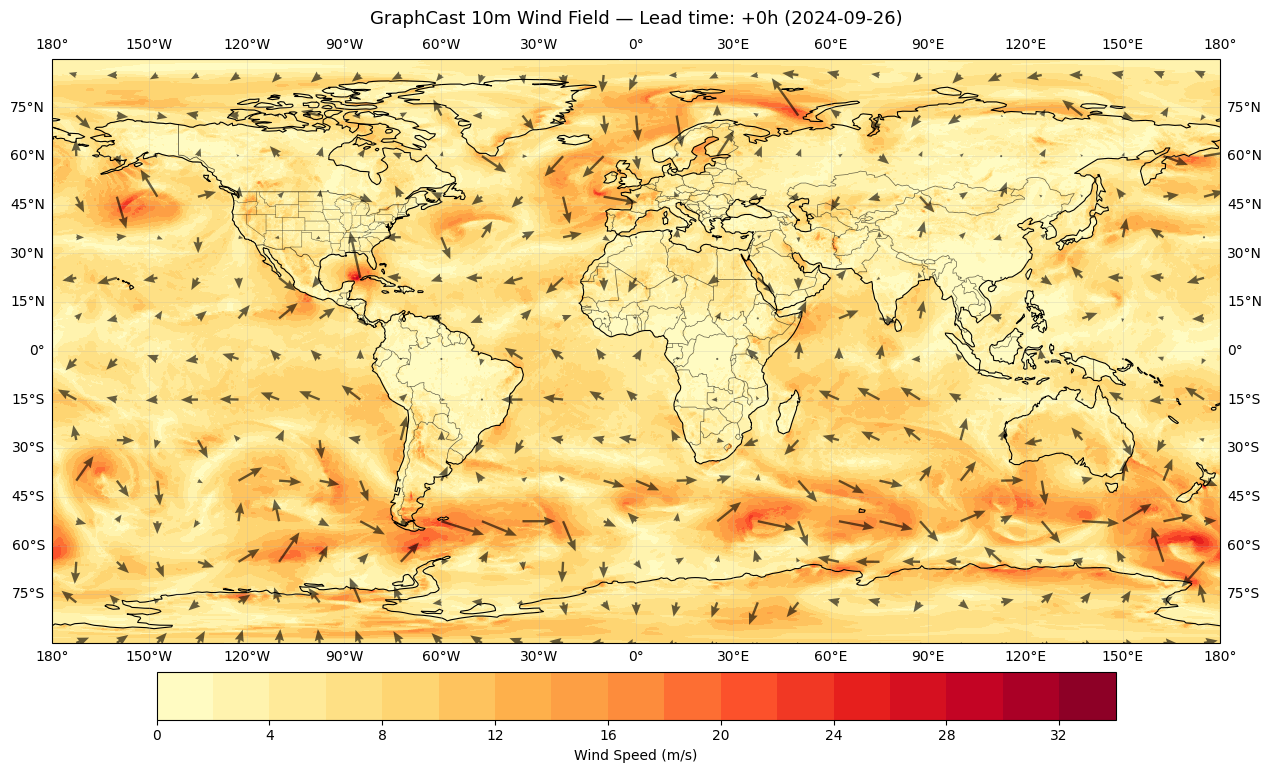

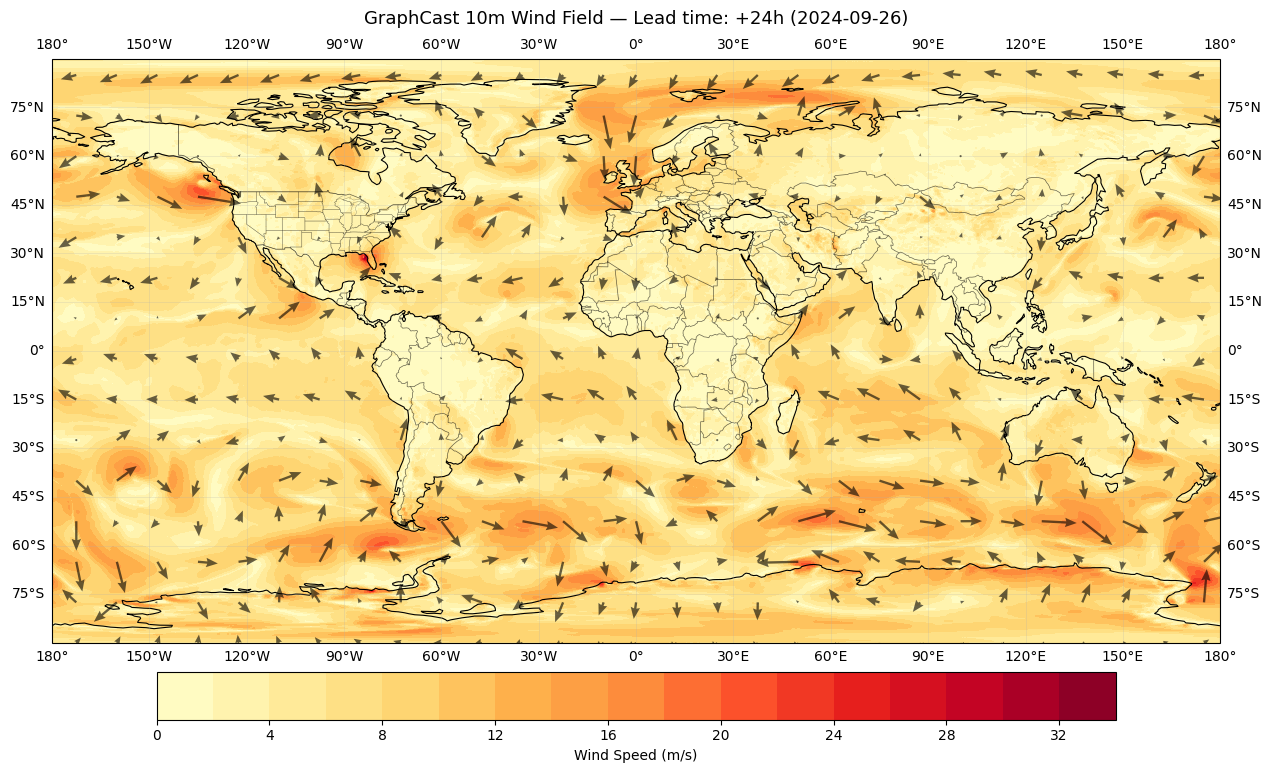

In [34]:
# times = [0, 4, 8, 16]
times = [0, 4]
for step in times:
    plot_wind_field(
        ds,
        step=step,
        extent=None,
        quiver_stride=50,
        save_path=f"outputs/wind_outputs/images/global_wind_step{step:02d}.jpg"
    )

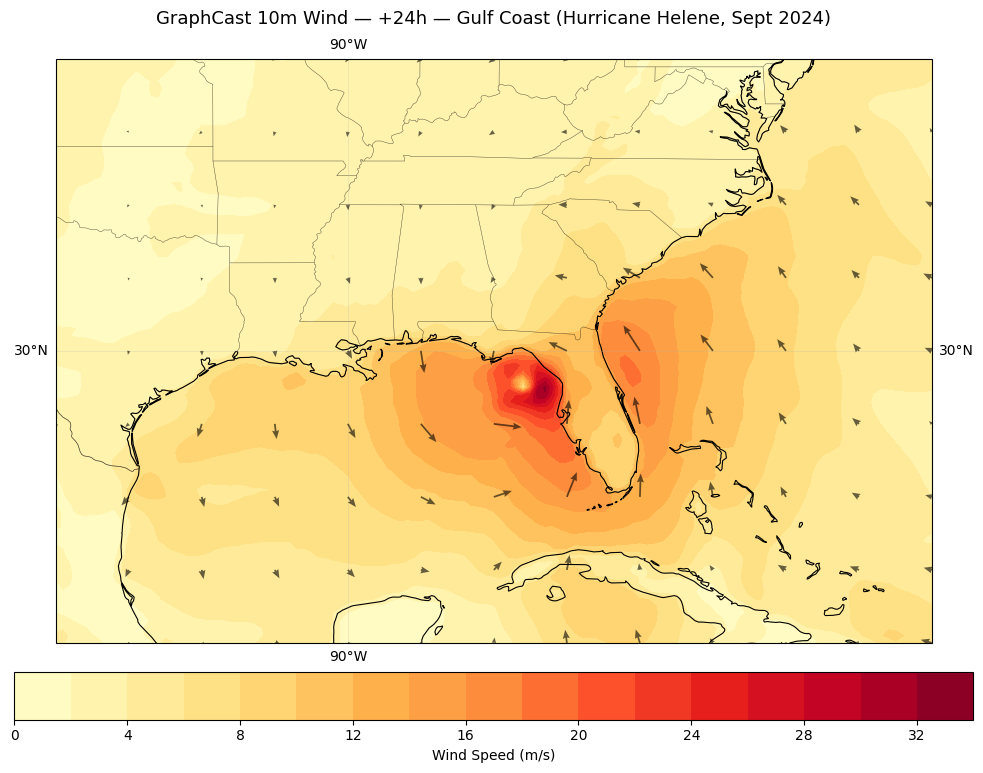

In [35]:
#Florida
plot_wind_field(
    ds,
    step=4,           # +24h forecast
    extent=[-100, -70, 20, 40],
    quiver_stride=10,  # denser arrows for regional zoom
    title="GraphCast 10m Wind — +24h — Gulf Coast (Hurricane Helene, Sept 2024)",
    save_path="outputs/wind_outputs/images/gulf_coast_wind_step04.jpg"
)


'''
Notes:
-temperature as color, pressure as contour (or vice versa)
-color bar (reduce length, make more narrow)
'''